# ARTI406 - Assignment 1  
## Exploratory Data Analysis for Messy E-commerce Sales Data

**Student name:** Wala Almukhtar  
**Dataset file:** `messy_ecommerce_sales_data.csv`

This notebook performs:
- data loading
- initial inspection
- data cleaning
- visualization
- insights

##The dataset before cleaning:

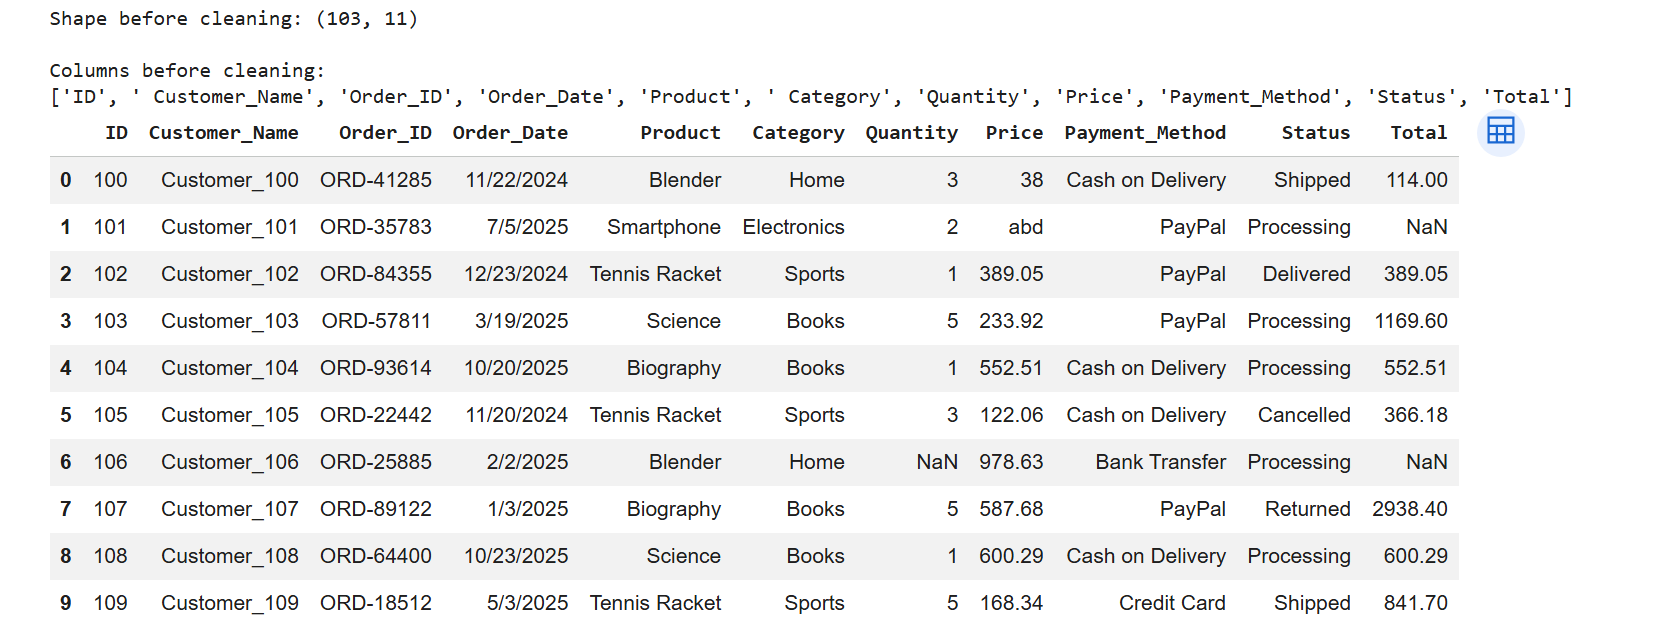

## The dataset after cleaning:

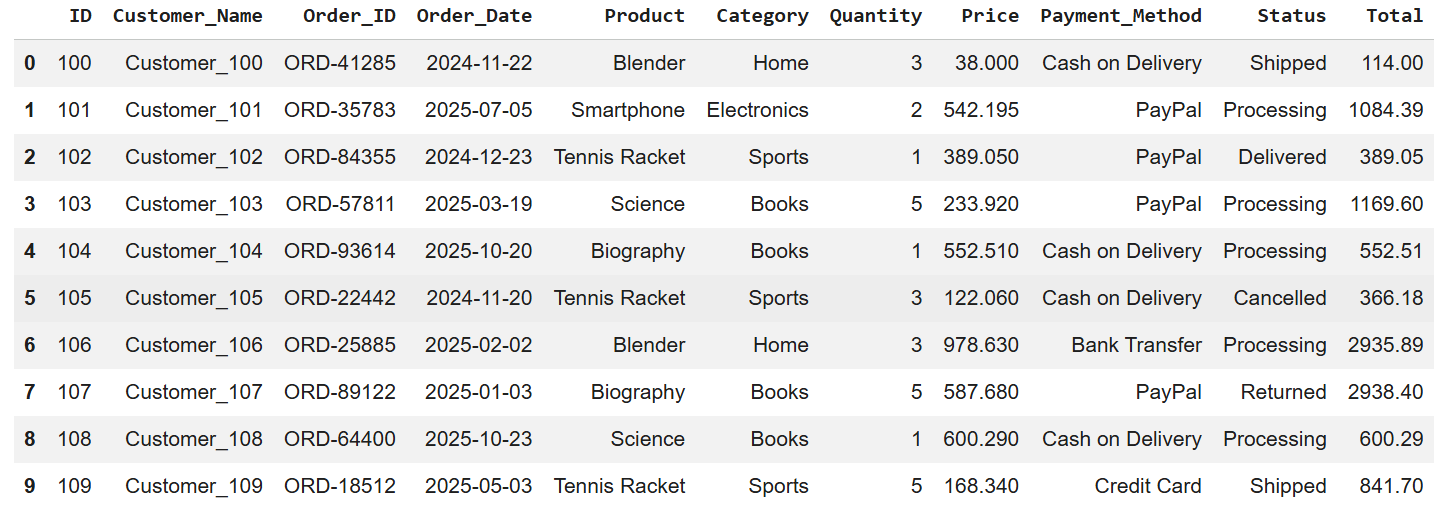


In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)

In [4]:
# Load dataset
df = pd.read_csv("messy_ecommerce_sales_data.csv")
df.head()

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
0,100,Customer_100,ORD-41285,11/22/2024,Blender,Home,3,38,Cash on Delivery,Shipped,114.00
1,101,Customer_101,ORD-35783,7/5/2025,Smartphone,Electronics,2,abd,PayPal,Processing,NaN
2,102,Customer_102,ORD-84355,12/23/2024,Tennis Racket,Sports,1,389.05,PayPal,Delivered,389.05
3,103,Customer_103,ORD-57811,3/19/2025,Science,Books,5,233.92,PayPal,Processing,1169.60
4,104,Customer_104,ORD-93614,10/20/2025,Biography,Books,1,552.51,Cash on Delivery,Processing,552.51


## 1) Initial inspection
The dataset before cleaning.  


In [5]:
# Shape, columns, and sample rows before cleaning
print("Shape before cleaning:", df.shape)
print("\nColumns before cleaning:")
print(df.columns.tolist())
display(df.head(10))

Shape before cleaning: (103, 11)

Columns before cleaning:
['ID', ' Customer_Name', 'Order_ID', 'Order_Date', 'Product', ' Category', 'Quantity', 'Price', 'Payment_Method', 'Status', 'Total']


,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
0,100,Customer_100,ORD-41285,11/22/2024,Blender,Home,3,38,Cash on Delivery,Shipped,114.00
1,101,Customer_101,ORD-35783,7/5/2025,Smartphone,Electronics,2,abd,PayPal,Processing,NaN
2,102,Customer_102,ORD-84355,12/23/2024,Tennis Racket,Sports,1,389.05,PayPal,Delivered,389.05
3,103,Customer_103,ORD-57811,3/19/2025,Science,Books,5,233.92,PayPal,Processing,1169.60
4,104,Customer_104,ORD-93614,10/20/2025,Biography,Books,1,552.51,Cash on Delivery,Processing,552.51
5,105,Customer_105,ORD-22442,11/20/2024,Tennis Racket,Sports,3,122.06,Cash on Delivery,Cancelled,366.18
6,106,Customer_106,ORD-25885,2/2/2025,Blender,Home,NaN,978.63,Bank Transfer,Processing,NaN
7,107,Customer_107,ORD-89122,1/3/2025,Biography,Books,5,587.68,PayPal,Returned,2938.40
8,108,Customer_108,ORD-64400,10/23/2025,Science,Books,1,600.29,Cash on Delivery,Processing,600.29
9,109,Customer_109,ORD-18512,5/3/2025,Tennis Racket,Sports,5,168.34,Credit Card,Shipped,841.70


In [6]:
# Missing values before cleaning
df.isna().sum()

,0
ID,0
Customer_Name,0
Order_ID,0
Order_Date,0
Product,0
Category,8
Quantity,5
Price,5
Payment_Method,0
Status,0


In [7]:
# Duplicate rows before cleaning
print("Duplicate rows before cleaning:", df.duplicated().sum())

Duplicate rows before cleaning: 1


In [8]:
# Data types before cleaning
df.dtypes

,0
ID,int64
Customer_Name,object
Order_ID,object
Order_Date,object
Product,object
Category,object
Quantity,object
Price,object
Payment_Method,object
Status,object


## 2) Data cleaning

### Cleaning steps performed
1. Removed extra spaces from column names.
2. Standardized text values in the `Category` column.
3. Converted `Order_Date` to datetime format.
4. Converted `Quantity` and `Price` to numeric values.
5. Replaced invalid quantities (non-numeric or negative) with missing values.
6. Replaced invalid prices (non-numeric or non-positive) with missing values.
7. Filled missing `Category` values with `Unknown`.
8. Filled missing numeric values using the median.
9. Recalculated `Total = Quantity × Price`.
10. Removed duplicate rows.

### Why cleaning was needed
The dataset contained:
- missing values
- duplicate rows
- inconsistent category names such as `sports`, `electronic`, and `ELECTRONICS`
- invalid numeric entries such as `4a`, `abd`, and `four hundred`
- negative quantities
- mixed date formats

In [9]:
# Make a copy for cleaning
df_cleaned = df.copy()

# 1) Clean column names
df_cleaned.columns = df_cleaned.columns.str.strip()

# 2) Standardize category values
df_cleaned["Category"] = df_cleaned["Category"].replace({
    "sports": "Sports",
    "electronic": "Electronics",
    "ELECTRONICS": "Electronics",
    "electronics": "Electronics"
})

# 3) Fill missing category values
df_cleaned["Category"] = df_cleaned["Category"].fillna("Unknown")

# 4) Convert dates
df_cleaned["Order_Date"] = pd.to_datetime(df_cleaned["Order_Date"], errors="coerce")

# 5) Remove original duplicate rows first
df_cleaned = df_cleaned.drop_duplicates().reset_index(drop=True)

# 6) Convert quantity and price to numeric
df_cleaned["Quantity"] = pd.to_numeric(df_cleaned["Quantity"], errors="coerce")
df_cleaned["Price"] = pd.to_numeric(df_cleaned["Price"], errors="coerce")

# 7) Invalid negative or zero values become missing
df_cleaned.loc[df_cleaned["Quantity"] <= 0, "Quantity"] = np.nan
df_cleaned.loc[df_cleaned["Price"] <= 0, "Price"] = np.nan

# 8) Fill missing numeric values with median
df_cleaned["Quantity"] = df_cleaned["Quantity"].fillna(df_cleaned["Quantity"].median())
df_cleaned["Price"] = df_cleaned["Price"].fillna(df_cleaned["Price"].median())

# Round quantity and convert to integer because quantity should be a whole number
df_cleaned["Quantity"] = df_cleaned["Quantity"].round().astype(int)

# 9) Recalculate total
df_cleaned["Total"] = (df_cleaned["Quantity"] * df_cleaned["Price"]).round(2)

# 10) Remove any duplicates that still remain after standardization
df_cleaned = df_cleaned.drop_duplicates().reset_index(drop=True)

print("Cleaning completed.")

Cleaning completed.


In [10]:
# Compare before and after
print("Shape before cleaning:", df.shape)
print("Shape after cleaning :", df_cleaned.shape)

print("\nMissing values after cleaning:")
display(df_cleaned.isna().sum())

print("\nDuplicate rows after cleaning:", df_cleaned.duplicated().sum())

Shape before cleaning: (103, 11)
Shape after cleaning : (100, 11)

Missing values after cleaning:


,0
ID,0
Customer_Name,0
Order_ID,0
Order_Date,2
Product,0
Category,0
Quantity,0
Price,0
Payment_Method,0
Status,0



Duplicate rows after cleaning: 0


In [11]:
# Display cleaned dataset
df_cleaned.head(10)

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
0,100,Customer_100,ORD-41285,2024-11-22,Blender,Home,3,38.000,Cash on Delivery,Shipped,114.00
1,101,Customer_101,ORD-35783,2025-07-05,Smartphone,Electronics,2,542.195,PayPal,Processing,1084.39
2,102,Customer_102,ORD-84355,2024-12-23,Tennis Racket,Sports,1,389.050,PayPal,Delivered,389.05
3,103,Customer_103,ORD-57811,2025-03-19,Science,Books,5,233.920,PayPal,Processing,1169.60
4,104,Customer_104,ORD-93614,2025-10-20,Biography,Books,1,552.510,Cash on Delivery,Processing,552.51
5,105,Customer_105,ORD-22442,2024-11-20,Tennis Racket,Sports,3,122.060,Cash on Delivery,Cancelled,366.18
6,106,Customer_106,ORD-25885,2025-02-02,Blender,Home,3,978.630,Bank Transfer,Processing,2935.89
7,107,Customer_107,ORD-89122,2025-01-03,Biography,Books,5,587.680,PayPal,Returned,2938.40
8,108,Customer_108,ORD-64400,2025-10-23,Science,Books,1,600.290,Cash on Delivery,Processing,600.29
9,109,Customer_109,ORD-18512,2025-05-03,Tennis Racket,Sports,5,168.340,Credit Card,Shipped,841.70


## 3) Descriptive statistics

In [12]:
df_cleaned.describe(include="all")

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
count,100.000000,100,100,98,100,100,100.000000,100.000000,100,100,100.000000
unique,NaN,100,100,NaN,21,6,NaN,NaN,4,5,NaN
top,NaN,Customer_100,ORD-41285,NaN,Blender,Books,NaN,NaN,Cash on Delivery,Returned,NaN
freq,NaN,1,1,NaN,8,22,NaN,NaN,33,27,NaN
mean,149.500000,NaN,NaN,2025-04-23 15:55:06.122448896,NaN,NaN,3.060000,616.811600,NaN,NaN,1903.850000
min,100.000000,NaN,NaN,2023-01-05 00:00:00,NaN,NaN,1.000000,38.000000,NaN,NaN,40.950000
25%,124.750000,NaN,NaN,2025-02-09 00:00:00,NaN,NaN,2.000000,341.435000,NaN,NaN,738.885000
50%,149.500000,NaN,NaN,2025-05-18 12:00:00,NaN,NaN,3.000000,542.195000,NaN,NaN,1513.950000
75%,174.250000,NaN,NaN,2025-08-01 12:00:00,NaN,NaN,4.000000,711.795000,NaN,NaN,2418.512500
max,199.000000,NaN,NaN,2025-11-06 00:00:00,NaN,NaN,5.000000,10000.000000,NaN,NaN,30000.000000


## 4) Visualizations and insights


### Plot 1: Order status distribution


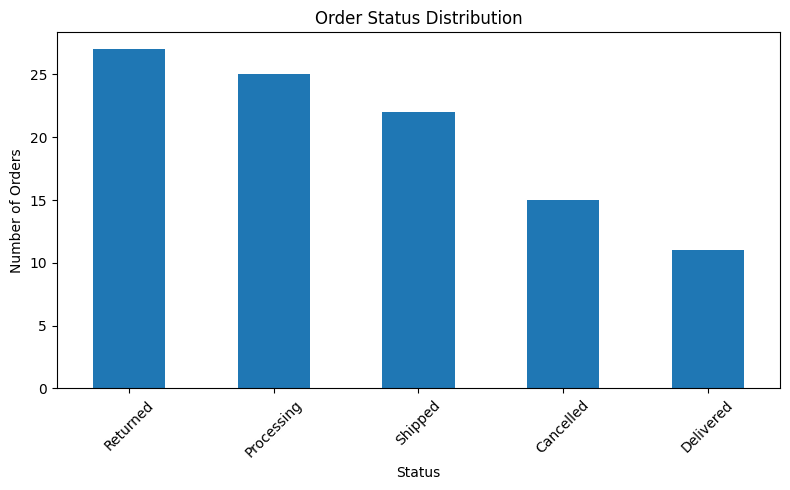

In [13]:
status_counts = df_cleaned["Status"].value_counts()

plt.figure()
status_counts.plot(kind="bar")
plt.title("Order Status Distribution")
plt.xlabel("Status")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This plot shows which order status appears most often, such as Delivered, Shipped, Processing, Cancelled, or Returned.

### Plot 2: Category distribution


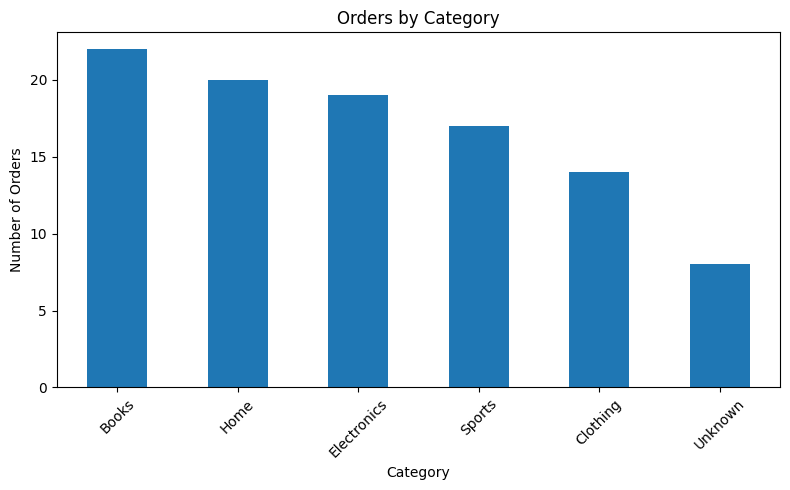

In [14]:
category_counts = df_cleaned["Category"].value_counts()

plt.figure()
category_counts.plot(kind="bar")
plt.title("Orders by Category")
plt.xlabel("Category")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This chart shows the number of orders in each product category, which helps to identify the most common categories in the dataset.

### Plot 3: Payment method distribution


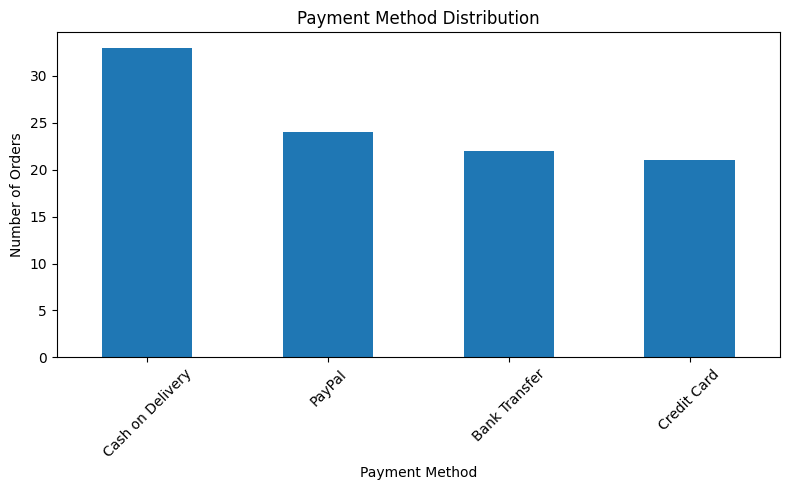

In [15]:
payment_counts = df_cleaned["Payment_Method"].value_counts()

plt.figure()
payment_counts.plot(kind="bar")
plt.title("Payment Method Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This plot compares customer payment preferences. It shows which payment method is used most often.

### Plot 4: Quantity distribution


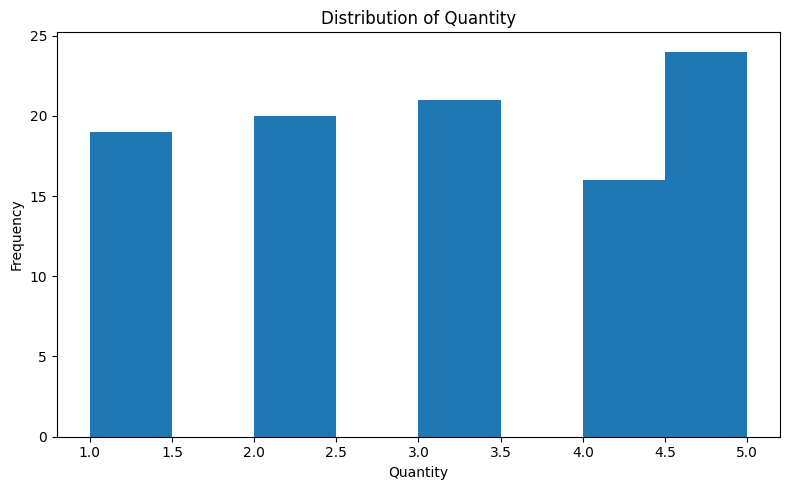

In [16]:
plt.figure()
plt.hist(df_cleaned["Quantity"], bins=8)
plt.title("Distribution of Quantity")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

A histogram is appropriate for showing how numeric values are distributed. It shows whether customers usually buy small or large quantities.

### Plot 5: Price distribution


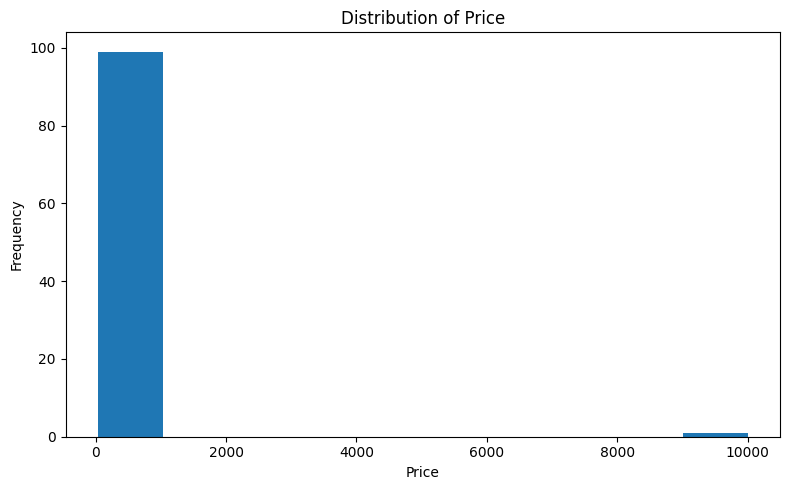

In [17]:
plt.figure()
plt.hist(df_cleaned["Price"], bins=10)
plt.title("Distribution of Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

This helps understand the spread of product prices and whether there are expensive outliers. The distribution indicates whether most products are low-priced or high-priced.

### Plot 6: Total sales by category


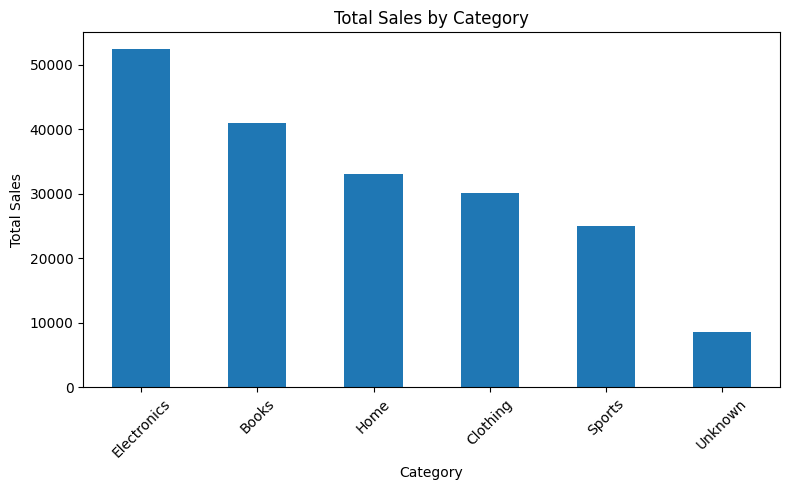

,Total
Category,
Electronics,52435.56
Books,41068.08
Home,33087.54
Clothing,30083.11
Sports,25076.32
Unknown,8634.39


In [18]:
sales_by_category = df_cleaned.groupby("Category")["Total"].sum().sort_values(ascending=False)

plt.figure()
sales_by_category.plot(kind="bar")
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

sales_by_category


A bar chart clearly compares total revenue across categories. This shows which category contributes the most sales.

### Plot 7: Top 10 products by total sales


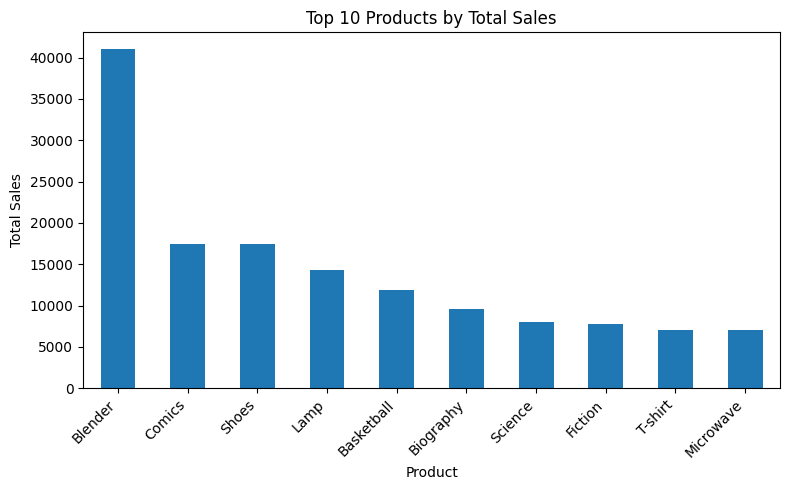

,Total
Product,
Blender,41011.27
Comics,17439.61
Shoes,17398.69
Lamp,14306.44
Basketball,11896.59
Biography,9577.39
Science,8005.71
Fiction,7761.57
T-shirt,7047.20


In [19]:
top_products = df_cleaned.groupby("Product")["Total"].sum().sort_values(ascending=False).head(10)

plt.figure()
top_products.plot(kind="bar")
plt.title("Top 10 Products by Total Sales")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

top_products

This chart highlights the best-performing products in terms of revenue. It reveals which products contribute the most to overall sales.

### Plot 8: Monthly sales trend


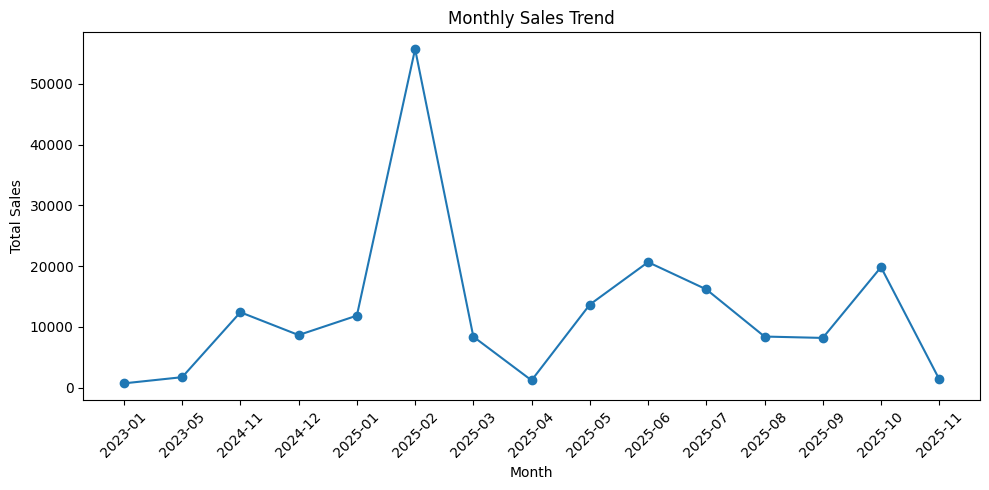

,Total
Month,
2023-01,705.78
2023-05,1721.98
2024-11,12407.74
2024-12,8654.39
2025-01,11851.43
2025-02,55716.73
2025-03,8386.83
2025-04,1200.28
2025-05,13670.00


In [20]:
time_df = df_cleaned.dropna(subset=["Order_Date"]).copy()
time_df["Month"] = time_df["Order_Date"].dt.to_period("M").astype(str)

monthly_sales = time_df.groupby("Month")["Total"].sum().sort_index()

plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

monthly_sales

A line chart is the best choice for showing change over time. This shows how sales changed across months and whether there are peaks or drops.

### Plot 9: Correlation matrix


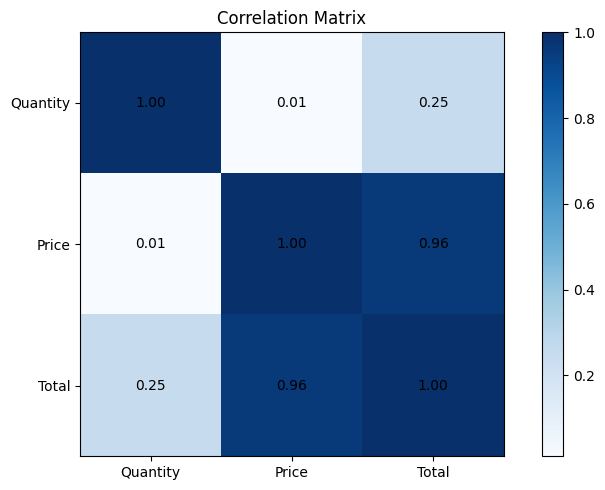

,Quantity,Price,Total
Quantity,1.000000,0.011686,0.254617
Price,0.011686,1.000000,0.962814
Total,0.254617,0.962814,1.000000


In [21]:
corr = df_cleaned[["Quantity", "Price", "Total"]].corr()

plt.figure()
plt.imshow(corr, cmap="Blues", interpolation="nearest")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")
plt.tight_layout()
plt.show()

corr

A correlation heatmap helps identify relationships between numeric variables. It shows whether variables such as Quantity, Price, and Total move together.

## 5) Main findings

In [24]:
print("Top category by sales:")
display(sales_by_category.head(1))

print("Top product by sales:")
display(top_products.head(1))

print("Most used payment method:")
display(df_cleaned["Payment_Method"].value_counts().head(1))

print("Most common order status:")
display(df_cleaned["Status"].value_counts().head(1))

Top category by sales:


,Total
Category,
Electronics,52435.56


Top product by sales:


,Total
Product,
Blender,41011.27


Most used payment method:


,count
Payment_Method,
Cash on Delivery,33


Most common order status:


,count
Status,
Returned,27


### Written insights summary
You can use or edit the following points in your report submission:

- The dataset required cleaning because it contained missing values, duplicate rows, invalid numeric values, inconsistent category labels, and mixed date formats.
- After cleaning, the data became more consistent and suitable for analysis.
- The visualizations show the distribution of order statuses, categories, payment methods, quantities, and prices.
- Sales analysis reveals which categories and products generate the highest revenue.
- The monthly trend chart helps identify changes in sales over time.
- The correlation matrix shows the strength of the relationship between Quantity, Price, and Total.
- Overall, the EDA helps understand customer purchasing behavior, product performance, and sales patterns.